In [1]:
# utils.py - روش نهایی و دائمی
import os
import requests
import gzip
import numpy as np
import struct

DATA_DIR = './mnist_data'
BASE_URL = "https://raw.githubusercontent.com/fgnt/mnist/master"

def load_mnist_from_github(cache_dir=DATA_DIR):
    """
    بارگذاری دیتاست از گیت‌هاب. اگر فایل‌ها در cache_dir موجود باشند، 
    فقط از روی هارد خوانده می‌شوند و دیگر دانلودی در کار نیست.
    """
    os.makedirs(cache_dir, exist_ok=True)
    
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    
    raw_data = {}
    for name, filename in files.items():
        filepath = os.path.join(cache_dir, filename)
        
        # دانلود فقط در صورتی که فایل وجود نداشته باشد
        if not os.path.exists(filepath):
            print(f"Downloading {filename} from GitHub...")
            url = f"{BASE_URL}/{filename}"
            response = requests.get(url, timeout=15)
            response.raise_for_status()
            with open(filepath, 'wb') as f:
                f.write(response.content)
            print(f"Saved to {filepath}")
        else:
            print(f"Found {filename} on disk. Loading...")
        
        # خواندن فایل از روی دیسک
        with gzip.open(filepath, 'rb') as f:
            raw_data[name] = f.read()

    # پارس کردن
    def parse_images(raw):
        magic, num, rows, cols = struct.unpack('>IIII', raw[:16])
        return np.frombuffer(raw[16:], dtype=np.uint8).reshape(num, rows, cols)

    def parse_labels(raw):
        magic, num = struct.unpack('>II', raw[:8])
        return np.frombuffer(raw[8:], dtype=np.uint8)

    X_train = parse_images(raw_data['train_images'])
    y_train = parse_labels(raw_data['train_labels'])
    X_test = parse_images(raw_data['test_images'])
    y_test = parse_labels(raw_data['test_labels'])
    
    return (X_train, y_train), (X_test, y_test)

In [2]:
import matplotlib.pyplot as plt
# به انتهای فایل utils.py اضافه کن

def show_sample_images(X, y, num_samples=10, title="MNIST Samples"):
    """
    Display sample images from the dataset.
    
    Args:
        X: Image array of shape (n, 28, 28)
        y: Label array of shape (n,)
        num_samples: Number of images to show
        title: Title for the plot
    """
    # انتخاب تصادفی نمونه‌ها
    indices = np.random.choice(len(X), num_samples, replace=False)
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i+1)
        plt.imshow(X[idx], cmap='gray')
        plt.title(f"Label: {y[idx]}", fontsize=12, fontweight='bold')
        plt.axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [3]:
#from utils import load_and_prepare_data, show_sample_images

# بارگذاری داده‌ها از گیت‌هاب
(X_train, y_train), (X_test, y_test) = load_mnist_from_github()



Saved to ./mnist_data/train-images-idx3-ubyte.gz
Saved to ./mnist_data/train-labels-idx1-ubyte.gz
Saved to ./mnist_data/t10k-images-idx3-ubyte.gz
Saved to ./mnist_data/t10k-labels-idx1-ubyte.gz


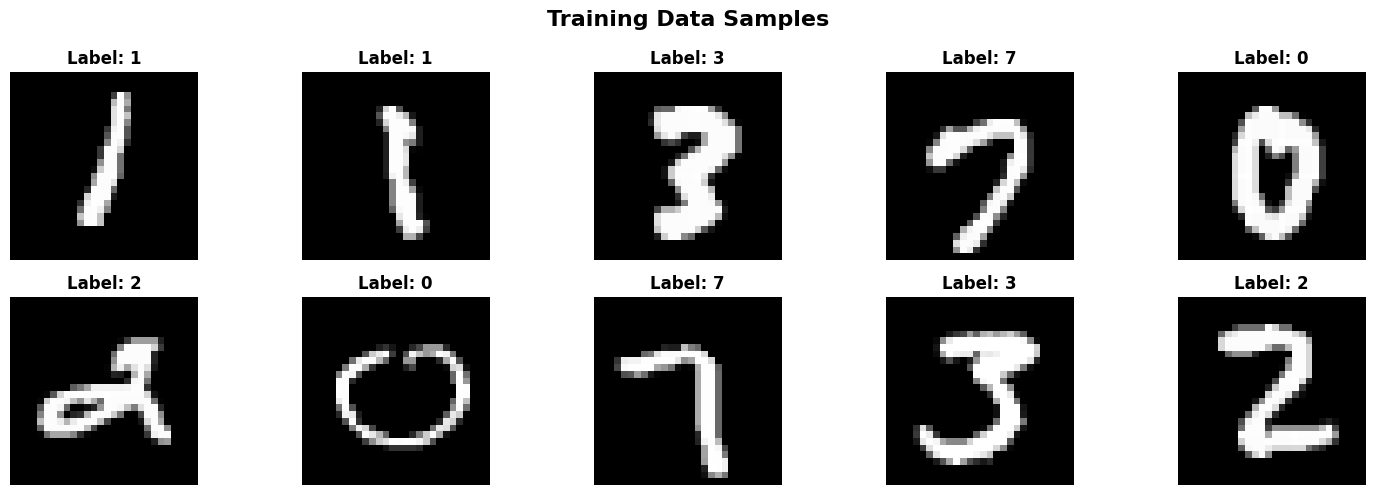

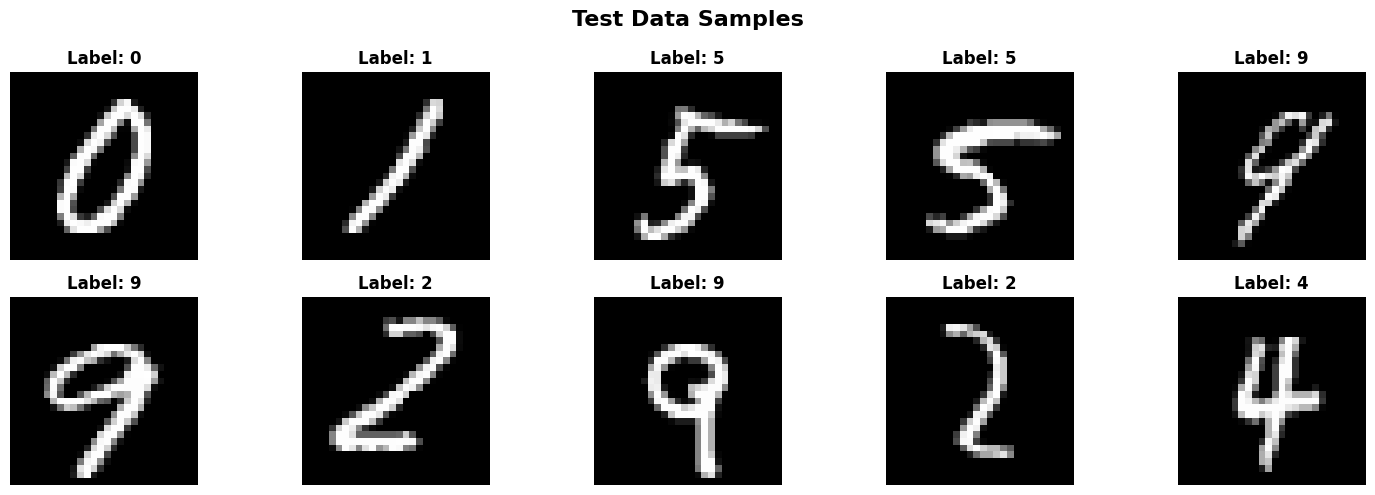

In [12]:
# دیدن ۱۰ تصویر تصادفی از دیتاست آموزش
show_sample_images(X_train, y_train, num_samples=10, title="Training Data Samples")

# دیدن ۱۰ تصویر تصادفی از دیتاست تست
show_sample_images(X_test, y_test, num_samples=10, title="Test Data Samples")